#📌 Extracción

In [39]:
import pandas as pd
df = pd.read_json('TelecomX_Data.json')
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   str   
 1   Churn       7267 non-null   str   
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(4), str(2)
memory usage: 340.8+ KB


#🔧 Transformación

In [41]:
cols = ['customer', 'phone', 'internet', 'account']

In [42]:
df_normalized = df.copy()

In [43]:
for col in cols:
    normalized = pd.json_normalize(df_normalized[col])
    normalized = normalized.add_prefix(col + '_')
    df_normalized = pd.concat([df_normalized.drop(columns=[col]), normalized], axis=1)

In [44]:
df_normalized.sample(10)

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
3886,5315-CKEQK,No,Male,1,Yes,Yes,28,Yes,Yes,DSL,...,No,No,No,No,No,One year,Yes,Electronic check,51.00,1381.8
6978,9614-RMGHA,Yes,Male,0,Yes,No,65,Yes,Yes,Fiber optic,...,Yes,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),91.85,5940.85
4719,6469-MRVET,No,Male,0,Yes,Yes,1,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Electronic check,20.20,20.2
1287,1849-RJYIG,No,Female,0,No,No,8,Yes,No,DSL,...,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,60.00,487.75
7239,9955-RVWSC,,Female,0,Yes,Yes,67,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),19.25,1372.9
2867,3976-NLDEZ,No,Male,0,No,No,1,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.60,20.6
2741,3795-CAWEX,No,Male,0,Yes,Yes,70,Yes,Yes,Fiber optic,...,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),116.55,8152.3
6234,8577-QSOCG,No,Female,0,Yes,Yes,38,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,20.20,746.05
4204,5777-KJIRB,No,Female,0,No,No,40,Yes,No,DSL,...,No,Yes,No,No,No,One year,Yes,Mailed check,50.25,2023.55
451,0639-QDHAY,,Female,0,No,No,22,Yes,No,Fiber optic,...,No,No,Yes,No,Yes,Month-to-month,Yes,Electronic check,89.05,1886.25


In [45]:
df_normalized.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   str    
 1   Churn                      7267 non-null   str    
 2   customer_gender            7267 non-null   str    
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   str    
 5   customer_Dependents        7267 non-null   str    
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   str    
 8   phone_MultipleLines        7267 non-null   str    
 9   internet_InternetService   7267 non-null   str    
 10  internet_OnlineSecurity    7267 non-null   str    
 11  internet_OnlineBackup      7267 non-null   str    
 12  internet_DeviceProtection  7267 non-null   str    
 13  internet_TechSupport       7267 non-null   str    
 14  int

In [46]:
df_normalized.columns.unique() 

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges.Monthly', 'account_Charges.Total'],
      dtype='str')

In [47]:
df_normalized = df_normalized.rename(columns=lambda x: x.lower())

In [48]:
df_normalized.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7267 non-null   str    
 1   churn                      7267 non-null   str    
 2   customer_gender            7267 non-null   str    
 3   customer_seniorcitizen     7267 non-null   int64  
 4   customer_partner           7267 non-null   str    
 5   customer_dependents        7267 non-null   str    
 6   customer_tenure            7267 non-null   int64  
 7   phone_phoneservice         7267 non-null   str    
 8   phone_multiplelines        7267 non-null   str    
 9   internet_internetservice   7267 non-null   str    
 10  internet_onlinesecurity    7267 non-null   str    
 11  internet_onlinebackup      7267 non-null   str    
 12  internet_deviceprotection  7267 non-null   str    
 13  internet_techsupport       7267 non-null   str    
 14  int

In [49]:
df_normalized.head()

,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges.monthly,account_charges.total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [50]:
df_normalized['cuentas_diarias'] = df_normalized['account_charges.monthly'] / 30

In [51]:
df_normalized.nunique()

customerid                   7267
churn                           3
customer_gender                 2
customer_seniorcitizen          2
customer_partner                2
customer_dependents             2
customer_tenure                73
phone_phoneservice              2
phone_multiplelines             3
internet_internetservice        3
internet_onlinesecurity         3
internet_onlinebackup           3
internet_deviceprotection       3
internet_techsupport            3
internet_streamingtv            3
internet_streamingmovies        3
account_contract                3
account_paperlessbilling        2
account_paymentmethod           4
account_charges.monthly      1585
account_charges.total        6531
cuentas_diarias              1585
dtype: int64

In [52]:
df_normalized['phone_multiplelines'].unique()

<StringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str

In [53]:
df_normalized.isin(["Yes","No"]).sum()

customerid                      0
churn                        7043
customer_gender                 0
customer_seniorcitizen          0
customer_partner             7267
customer_dependents          7267
customer_tenure                 0
phone_phoneservice           7267
phone_multiplelines          6560
internet_internetservice     1581
internet_onlinesecurity      5686
internet_onlinebackup        5686
internet_deviceprotection    5686
internet_techsupport         5686
internet_streamingtv         5686
internet_streamingmovies     5686
account_contract                0
account_paperlessbilling     7267
account_paymentmethod           0
account_charges.monthly         0
account_charges.total           0
cuentas_diarias                 0
dtype: int64

In [54]:
(df_normalized == "").sum()

customerid                     0
churn                        224
customer_gender                0
customer_seniorcitizen         0
customer_partner               0
customer_dependents            0
customer_tenure                0
phone_phoneservice             0
phone_multiplelines            0
internet_internetservice       0
internet_onlinesecurity        0
internet_onlinebackup          0
internet_deviceprotection      0
internet_techsupport           0
internet_streamingtv           0
internet_streamingmovies       0
account_contract               0
account_paperlessbilling       0
account_paymentmethod          0
account_charges.monthly        0
account_charges.total          0
cuentas_diarias                0
dtype: int64

In [55]:
df_normalized.shape

(7267, 22)

In [56]:
df_normalized = df_normalized.replace(r'^\s*$', pd.NA, regex=True)

In [57]:
(df_normalized == "").sum()

customerid                   0
churn                        0
customer_gender              0
customer_seniorcitizen       0
customer_partner             0
customer_dependents          0
customer_tenure              0
phone_phoneservice           0
phone_multiplelines          0
internet_internetservice     0
internet_onlinesecurity      0
internet_onlinebackup        0
internet_deviceprotection    0
internet_techsupport         0
internet_streamingtv         0
internet_streamingmovies     0
account_contract             0
account_paperlessbilling     0
account_paymentmethod        0
account_charges.monthly      0
account_charges.total        0
cuentas_diarias              0
dtype: int64

In [58]:
df_normalized.isna().sum()

customerid                     0
churn                        224
customer_gender                0
customer_seniorcitizen         0
customer_partner               0
customer_dependents            0
customer_tenure                0
phone_phoneservice             0
phone_multiplelines            0
internet_internetservice       0
internet_onlinesecurity        0
internet_onlinebackup          0
internet_deviceprotection      0
internet_techsupport           0
internet_streamingtv           0
internet_streamingmovies       0
account_contract               0
account_paperlessbilling       0
account_paymentmethod          0
account_charges.monthly        0
account_charges.total         11
cuentas_diarias                0
dtype: int64

In [59]:
df_normalized = df_normalized.dropna(subset=["churn"])

In [60]:
df_normalized = df_normalized.dropna(subset=["account_charges.total"])

In [61]:
df_normalized.isna().sum()

customerid                   0
churn                        0
customer_gender              0
customer_seniorcitizen       0
customer_partner             0
customer_dependents          0
customer_tenure              0
phone_phoneservice           0
phone_multiplelines          0
internet_internetservice     0
internet_onlinesecurity      0
internet_onlinebackup        0
internet_deviceprotection    0
internet_techsupport         0
internet_streamingtv         0
internet_streamingmovies     0
account_contract             0
account_paperlessbilling     0
account_paymentmethod        0
account_charges.monthly      0
account_charges.total        0
cuentas_diarias              0
dtype: int64

In [62]:
for col in df_normalized.select_dtypes("object").columns:
    print(col)
    print(df_normalized[col].value_counts())
    print()

customerid
customerid
0002-ORFBO    1
0003-MKNFE    1
0004-TLHLJ    1
0011-IGKFF    1
0013-EXCHZ    1
             ..
9987-LUTYD    1
9992-RRAMN    1
9992-UJOEL    1
9993-LHIEB    1
9995-HOTOH    1
Name: count, Length: 7032, dtype: int64

churn
churn
No     5163
Yes    1869
Name: count, dtype: int64

customer_gender
customer_gender
Male      3549
Female    3483
Name: count, dtype: int64

customer_partner
customer_partner
No     3639
Yes    3393
Name: count, dtype: int64

customer_dependents
customer_dependents
No     4933
Yes    2099
Name: count, dtype: int64

phone_phoneservice
phone_phoneservice
Yes    6352
No      680
Name: count, dtype: int64

phone_multiplelines
phone_multiplelines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

internet_internetservice
internet_internetservice
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

internet_onlinesecurity
internet_onlinesecurity
No               

C:\Users\dapar\AppData\Local\Temp\ipykernel_43024\760977511.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_normalized.select_dtypes("object").columns:


In [63]:
df_normalized = df_normalized.replace({
    "No internet service": "No",
    "No phone service": "No"
})

In [64]:
df_normalized.nunique()

customerid                   7032
churn                           2
customer_gender                 2
customer_seniorcitizen          2
customer_partner                2
customer_dependents             2
customer_tenure                72
phone_phoneservice              2
phone_multiplelines             2
internet_internetservice        3
internet_onlinesecurity         2
internet_onlinebackup           2
internet_deviceprotection       2
internet_techsupport            2
internet_streamingtv            2
internet_streamingmovies        2
account_contract                3
account_paperlessbilling        2
account_paymentmethod           4
account_charges.monthly      1584
account_charges.total        6530
cuentas_diarias              1584
dtype: int64

In [65]:
binary_cols = df_normalized.columns[df_normalized.nunique() == 2]

In [66]:
df_normalized[binary_cols] = df_normalized[binary_cols].replace({"Yes":1,"No":0})

In [67]:
df_normalized.head()

,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges.monthly,account_charges.total,cuentas_diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.3,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.4,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.4,2.796667


In [68]:
df_normalized = df_normalized.drop(columns="customerid")

In [69]:
df_normalized.head()

,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,internet_onlinesecurity,...,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges.monthly,account_charges.total,cuentas_diarias
0,0,Female,0,1,1,9,1,0,DSL,0,...,0,1,1,0,One year,1,Mailed check,65.6,593.3,2.186667
1,0,Male,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.4,1.996667
2,1,Male,0,0,0,4,1,0,Fiber optic,0,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,1,Male,1,1,0,13,1,0,Fiber optic,0,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,1,Female,1,1,0,3,1,0,Fiber optic,0,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.4,2.796667


In [70]:
df_normalized.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   churn                      7032 non-null   object 
 1   customer_gender            7032 non-null   str    
 2   customer_seniorcitizen     7032 non-null   int64  
 3   customer_partner           7032 non-null   object 
 4   customer_dependents        7032 non-null   object 
 5   customer_tenure            7032 non-null   int64  
 6   phone_phoneservice         7032 non-null   object 
 7   phone_multiplelines        7032 non-null   object 
 8   internet_internetservice   7032 non-null   str    
 9   internet_onlinesecurity    7032 non-null   object 
 10  internet_onlinebackup      7032 non-null   object 
 11  internet_deviceprotection  7032 non-null   object 
 12  internet_techsupport       7032 non-null   object 
 13  internet_streamingtv       7032 non-null   object 
 14  internet

In [71]:
df_normalized['customer_gender'] = df_normalized['customer_gender'].replace({"Male":1,"Female":0})


In [72]:
df_normalized[binary_cols] = df_normalized[binary_cols].astype("int64")

In [73]:
df_normalized['account_charges.total'] = df_normalized['account_charges.total'].astype("float64")

In [74]:
df_normalized.info()


<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   churn                      7032 non-null   int64  
 1   customer_gender            7032 non-null   int64  
 2   customer_seniorcitizen     7032 non-null   int64  
 3   customer_partner           7032 non-null   int64  
 4   customer_dependents        7032 non-null   int64  
 5   customer_tenure            7032 non-null   int64  
 6   phone_phoneservice         7032 non-null   int64  
 7   phone_multiplelines        7032 non-null   int64  
 8   internet_internetservice   7032 non-null   str    
 9   internet_onlinesecurity    7032 non-null   int64  
 10  internet_onlinebackup      7032 non-null   int64  
 11  internet_deviceprotection  7032 non-null   int64  
 12  internet_techsupport       7032 non-null   int64  
 13  internet_streamingtv       7032 non-null   int64  
 14  internet

#📊 Carga y análisis

In [75]:
df_normalized['account_charges.monthly'].describe()

count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: account_charges.monthly, dtype: float64

In [76]:
df_normalized['account_charges.total'].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: account_charges.total, dtype: float64

In [77]:
df_normalized['cuentas_diarias'].describe()

count    7032.000000
mean        2.159940
std         1.002866
min         0.608333
25%         1.186250
50%         2.345000
75%         2.995417
max         3.958333
Name: cuentas_diarias, dtype: float64

In [78]:
import matplotlib.pyplot as plt

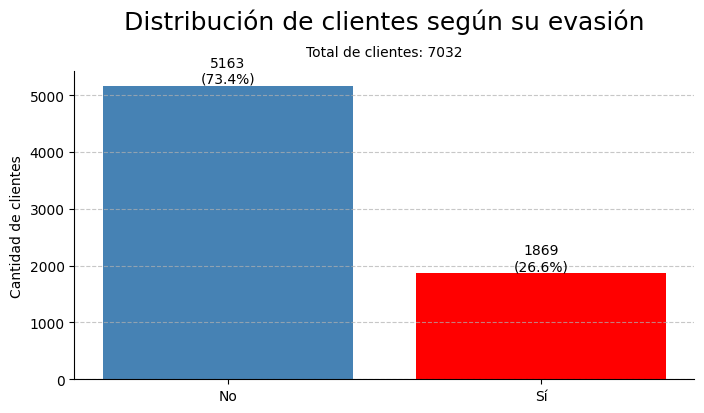

In [79]:
churn_counts = df_normalized["churn"].value_counts().sort_index()
total = churn_counts.sum()
churn_pct = churn_counts / total * 100
fig, ax = plt.subplots(figsize=(8,4))
colors = ["steelblue","red"]
ax.bar(["No","Sí"], churn_counts, color=colors)
ax.set_title("Distribución de clientes según su evasión", fontsize=18, pad=30)
ax.set_ylabel("Cantidad de clientes")
for i, (count, pct) in enumerate(zip(churn_counts, churn_pct)):
    ax.text(i, count + 50, f"{count}\n({pct:.1f}%)", ha="center")
ax.text(
    0.5,
    max(churn_counts) * 1.1,
    f"Total de clientes: {total}",
    ha="center"
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [80]:
import numpy as np

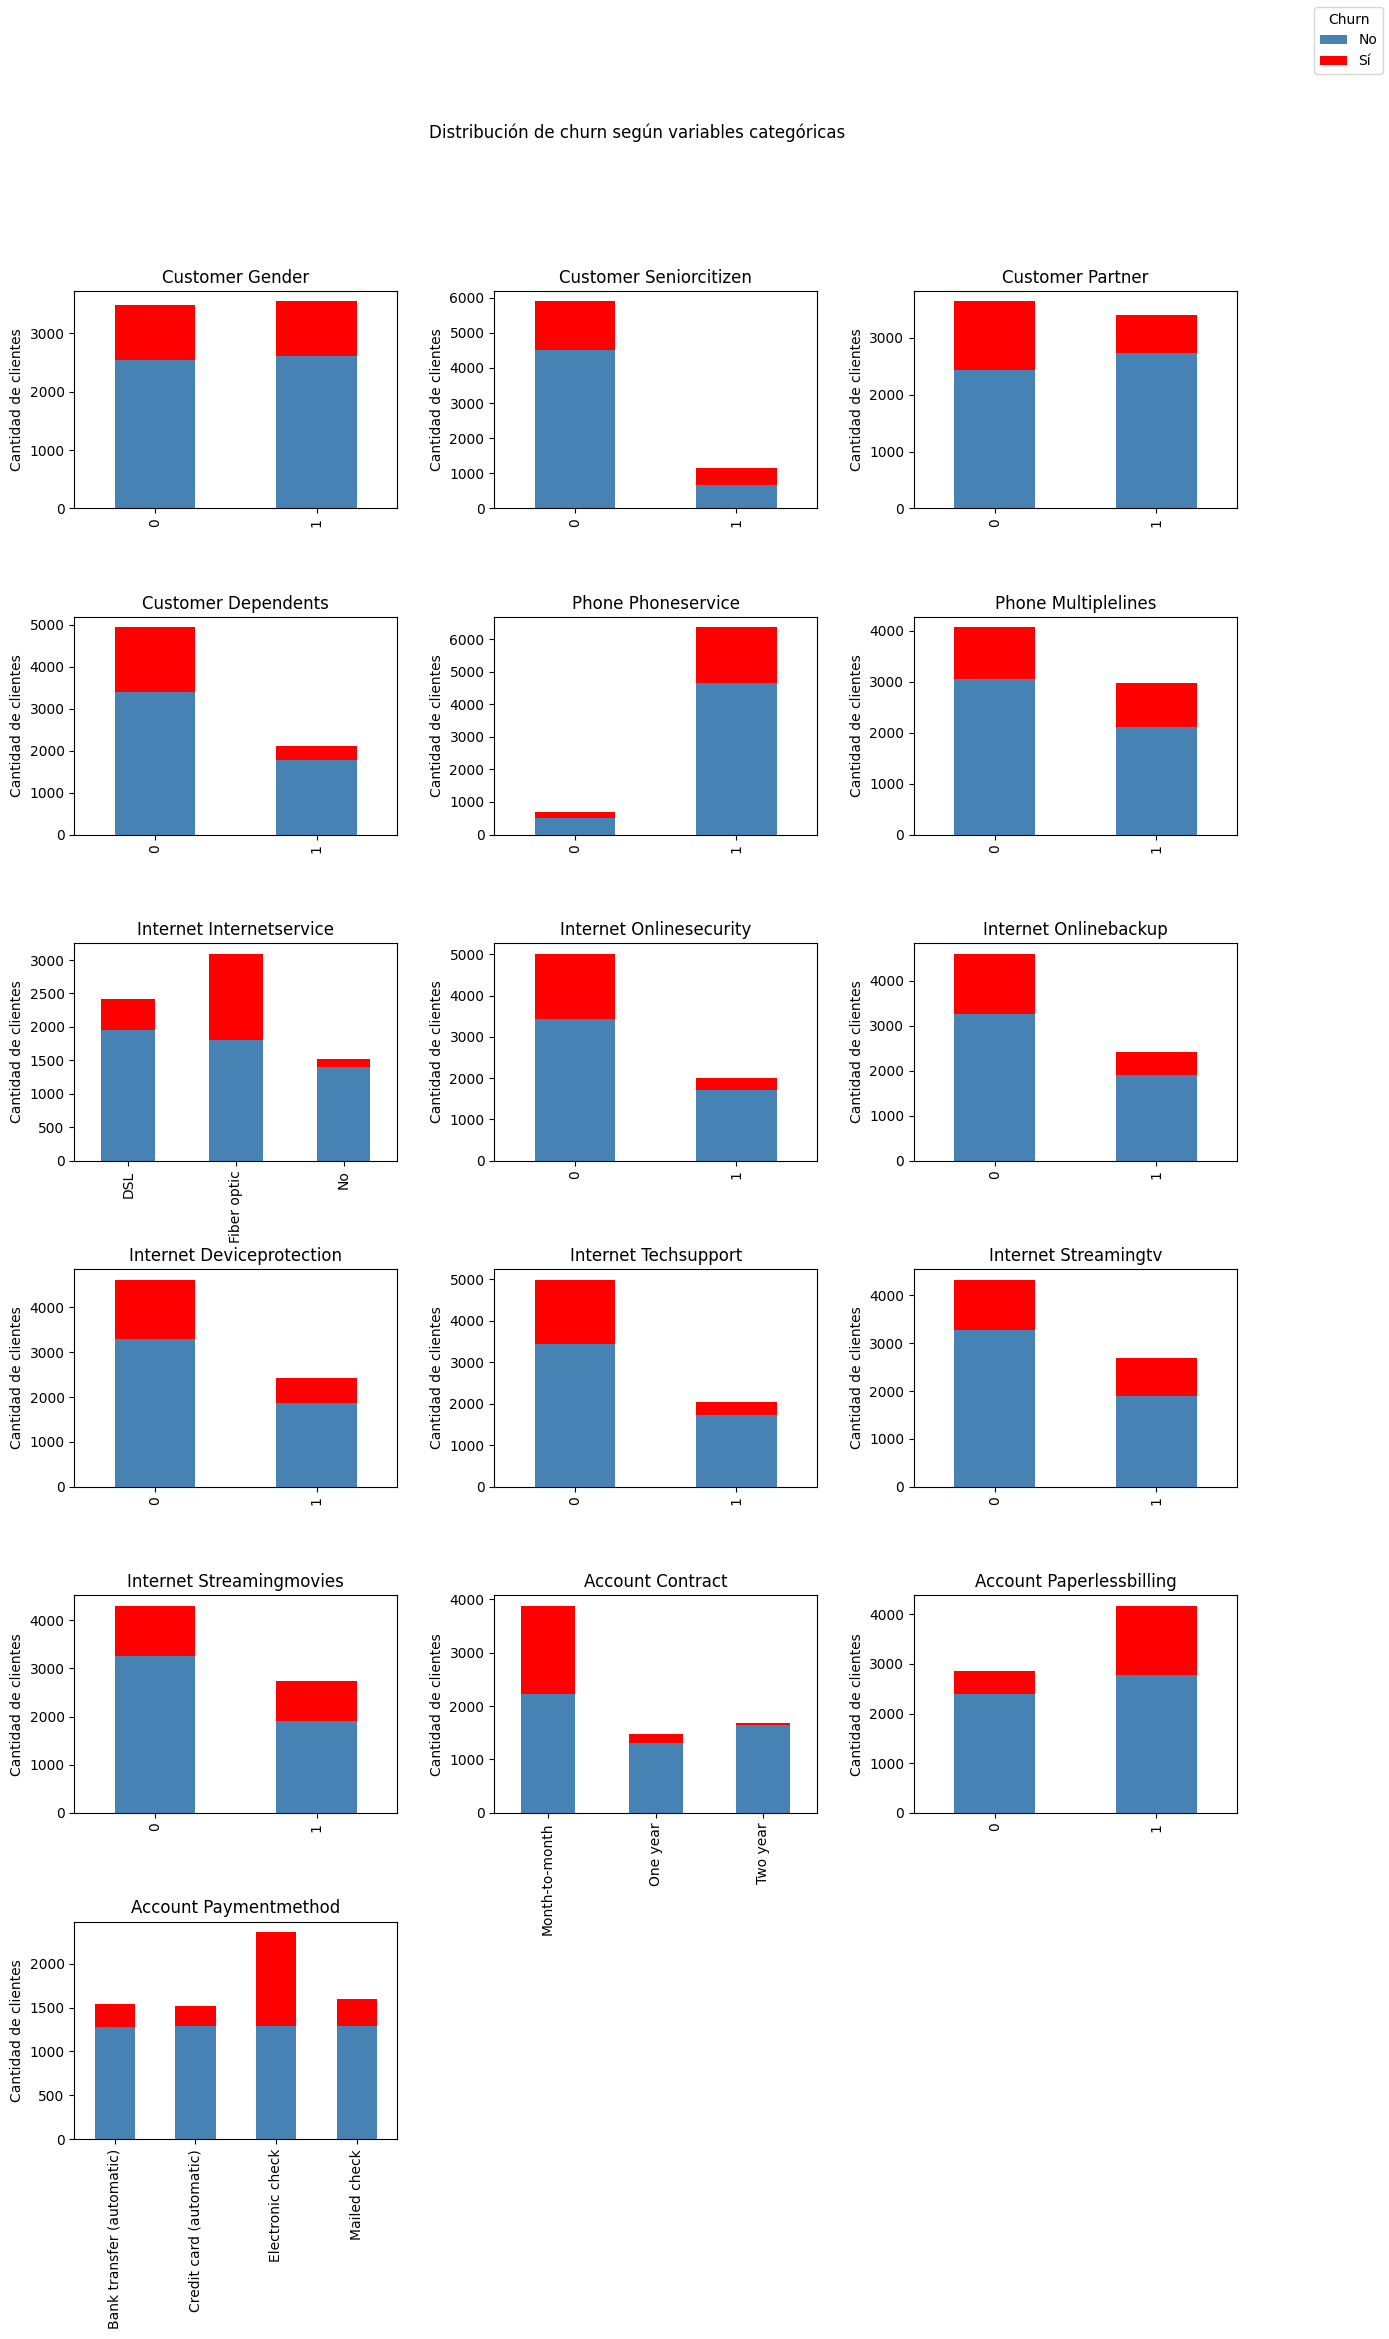

In [81]:
cat_cols = [col for col in df_normalized.columns
            if df_normalized[col].nunique() < 6
            and col != "churn"]
n = len(cat_cols)
cols = 3
rows = int(np.ceil(n/cols))

fig, axs = plt.subplots(rows, cols, figsize=(15, rows*4))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
fig.suptitle("Distribución de churn según variables categóricas", y=0.95)


for ax, col in zip(axs.ravel(), cat_cols):

    tabla = pd.crosstab(
        df_normalized[col],
        df_normalized["churn"],
        
    )

    tabla.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=["steelblue","red"],
        legend=False
    )

    ax.set_title(col.replace("_"," ").title())
    ax.set_xlabel("")
    ax.set_ylabel("Cantidad de clientes")
    

# eliminar ejes vacíos si sobran
for ax in axs.ravel()[len(cat_cols):]:
    ax.remove()

fig.legend(["No","Sí"], title="Churn", loc="upper right")

plt.show()

In [82]:
rename_cols = {
    "customer_tenure": "Antigüedad del cliente",
    "account_charges.monthly": "Cargos mensuales",
    "account_charges.total": "Gasto total",
    "churn": "Evasión de clientes"
}

df_normalized = df_normalized.rename(columns=rename_cols)

In [83]:
num_cols = [
    "Antigüedad del cliente",
    "Cargos mensuales",
    "Gasto total",
    "cuentas_diarias"
]



In [84]:
import seaborn as sns

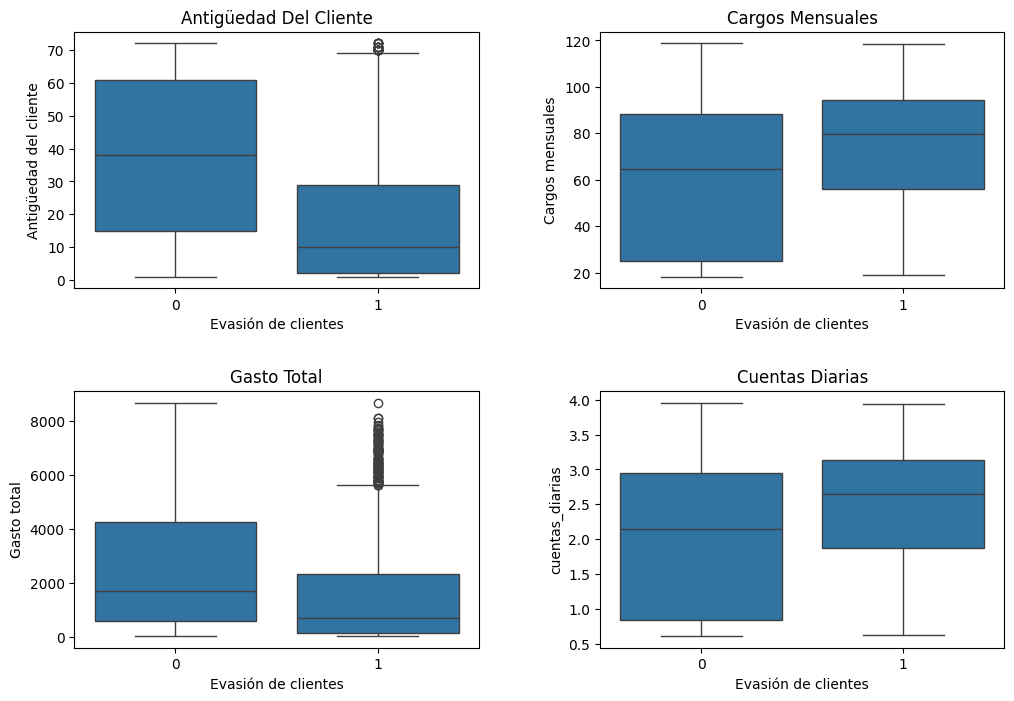

In [85]:
fig, axs = plt.subplots(2,2, figsize=(12,8))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

for ax, col in zip(axs.ravel(), num_cols):

    sns.boxplot(
        data=df_normalized,
        x="Evasión de clientes",
        y=col,
        ax=ax
    )

    ax.set_title(col.replace("_"," ").title())
    ax.set_xlabel("Evasión de clientes")

plt.show()

#📄Informe final

# Informe de Análisis de Evasión de Clientes (Churn)

## 1. Introducción

El presente análisis tiene como objetivo estudiar el fenómeno de evasión de clientes (Churn) en una empresa de telecomunicaciones, con el fin de identificar patrones y factores asociados a la cancelación del servicio.

La evasión de clientes es un problema relevante para las empresas, ya que implica pérdida de ingresos, mayores costos de adquisición de nuevos clientes y una disminución en la estabilidad del negocio. Por ello, comprender qué características tienen los clientes con mayor probabilidad de abandonar el servicio permite generar estrategias de retención más efectivas.

A través de este trabajo se realizó un proceso completo de importación, limpieza, transformación y análisis exploratorio de datos, buscando detectar relaciones entre la evasión y variables categóricas y numéricas del conjunto de datos.

## 2. Limpieza y Tratamiento de Datos

Para preparar los datos antes del análisis, se llevaron a cabo varias etapas de limpieza y transformación.

En primer lugar, se importó el archivo JSON, el cual contenía información estructurada con diccionarios anidados en varias columnas. Debido a esto, fue necesario normalizar dichas columnas para convertirlas en variables planas y utilizables dentro del DataFrame.

Posteriormente, se realizó un proceso de estandarización de nombres de columnas, transformándolos a minúsculas y eliminando caracteres como "_", con el objetivo de hacer el dataset más legible y fácil de manipular.

Luego, se creó una nueva variable denominada "cuentas_diarias", con el fin de enriquecer el análisis y disponer de una métrica complementaria derivada de la información original.

En cuanto a la calidad de los datos, se detectaron valores en blanco que no correspondían a información válida. Estos registros fueron primero transformados a valores nulos, para luego ser tratados adecuadamente. En los casos necesarios, los registros con datos faltantes fueron eliminados para evitar sesgos o errores en el análisis.

También se realizó la transformación de variables categóricas binarias a formato numérico, por ejemplo convirtiendo valores como "Yes" y "No" en 1 y 0, respectivamente. Esto permitió trabajar con mayor facilidad tanto en el análisis exploratorio como en eventuales modelos posteriores.

Finalmente, se corrigieron los tipos de datos de cada columna, asegurando que variables numéricas quedaran como int o float, y variables categóricas como string, según correspondiera. Esta etapa fue fundamental para garantizar coherencia y evitar errores durante las visualizaciones y cálculos estadísticos.

## 3. Análisis Exploratorio de Datos

Una vez finalizado el tratamiento de los datos, se procedió a desarrollar el análisis exploratorio, considerando tanto variables categóricas como numéricas.

### 3.1 Distribución general de la evasión

Se comenzó analizando la distribución de la variable churn, observando la proporción de clientes que permanecen en la compañía frente a aquellos que cancelan el servicio.

Este análisis permitió comprobar que la mayoría de los clientes se mantienen activos, aunque existe un grupo importante que presenta evasión. Esto confirma que el problema es relevante y justifica profundizar en los factores asociados a este comportamiento.

### 3.2 Análisis de variables categóricas

Posteriormente, se analizaron variables categóricas mediante gráficos de barras apiladas, con el objetivo de identificar qué categorías presentan una mayor proporción de churn.

Entre los hallazgos más relevantes, se observó que:

El tipo de contrato presenta una relación muy marcada con la evasión. Los clientes con contratos mes a mes muestran una mayor tendencia a cancelar el servicio, mientras que los contratos de uno o dos años presentan una tasa de evasión considerablemente menor.

El tipo de servicio de internet también muestra diferencias importantes. Se observó que ciertos servicios, como fibra óptica, concentran una mayor proporción de clientes con churn.

El método de pago presenta patrones diferenciados, destacando algunos métodos con una mayor tasa de evasión en comparación con otros.

En contraste, variables como el género presentan una distribución muy similar entre clientes que cancelan y los que no, por lo que no parecen ser un factor relevante en la evasión.

Este análisis permitió distinguir con rapidez cuáles variables categóricas parecen estar más asociadas al churn y cuáles tienen poco impacto.

### 3.3 Análisis de variables numéricas

Luego se exploraron variables numéricas como:

Antigüedad del cliente

Cargos mensuales

Gasto total

Cuentas diarias

Para este análisis se utilizaron gráficos comparativos que permitieron observar cómo se distribuyen estos valores entre clientes con churn y sin churn.

Los principales patrones observados fueron los siguientes:

Los clientes con menor antigüedad presentan una mayor tendencia a cancelar el servicio, lo que sugiere que la evasión ocurre con mayor frecuencia en etapas tempranas de la relación con la empresa.

Los clientes con cargos mensuales más altos muestran una mayor propensión a abandonar el servicio.

El gasto total tiende a ser menor entre los clientes que cancelan, lo que resulta coherente con una menor permanencia dentro de la compañía.

La variable cuentas diarias aporta una perspectiva complementaria sobre el comportamiento de gasto, permitiendo enriquecer la interpretación de los perfiles de clientes.

En conjunto, estas visualizaciones permitieron observar diferencias importantes entre ambos grupos y entender mejor qué características numéricas se relacionan con la evasión.

## 4. Conclusiones e Insights

A partir del análisis realizado, se concluye que la evasión de clientes no ocurre de manera aleatoria, sino que está asociada a ciertos perfiles y características específicas.

Los principales hallazgos fueron:

La evasión se concentra más en clientes con baja antigüedad, lo que indica que los primeros meses son críticos para la retención.

Los clientes con cargos mensuales elevados presentan una mayor probabilidad de cancelar el servicio.

El tipo de contrato es uno de los factores más influyentes: los contratos mes a mes presentan mucha mayor evasión que los contratos de mayor duración.

Algunas categorías del servicio de internet y del método de pago también evidencian comportamientos de churn más altos.

Variables como el género no muestran diferencias relevantes, por lo que su impacto en la evasión parece ser bajo o nulo.

En términos generales, los datos sugieren que los clientes más propensos a abandonar el servicio son aquellos que llevan poco tiempo en la empresa, pagan montos mensuales relativamente altos y poseen contratos menos estables.

## 5. Recomendaciones

A partir de los hallazgos obtenidos, se proponen las siguientes recomendaciones estratégicas para reducir la evasión de clientes:

### 5.1 Fortalecer la retención temprana

Dado que la mayor evasión se concentra en clientes nuevos, resulta clave implementar estrategias de acompañamiento durante los primeros meses, tales como:

seguimiento postventa,

soporte prioritario,

beneficios de bienvenida,

campañas de fidelización temprana.

### 5.2 Revisar la estructura de precios

Los mayores cargos mensuales parecen estar asociados con un mayor churn. Por ello, sería recomendable evaluar:

planes más competitivos,

descuentos por permanencia,

mejoras en la percepción de valor del servicio.

### 5.3 Incentivar contratos de mayor duración

Considerando que los contratos mes a mes presentan mayor evasión, se podrían diseñar estrategias para incentivar el paso a planes anuales o de largo plazo, por ejemplo:

descuentos,

beneficios exclusivos,

congelamiento de tarifas,

servicios adicionales incluidos.

### 5.4 Analizar segmentos específicos de internet y pago

El comportamiento observado en algunos tipos de servicio de internet y métodos de pago sugiere que existen segmentos con mayor riesgo de churn. Sería conveniente profundizar en esos grupos para:

identificar causas específicas,

diseñar campañas dirigidas,

personalizar ofertas de retención.

## 6. Cierre

En conclusión, el análisis permitió identificar variables clave relacionadas con la evasión de clientes y generar insights útiles para la toma de decisiones. El proceso de limpieza, transformación y exploración de datos fue fundamental para construir una base confiable desde la cual interpretar el comportamiento de los clientes.